In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

### Python Data Preprocessing for Deep-RegimeNet

In [ ]:
def get_regime_data(ticker="SPY", start="2005-01-01", end="2025-01-01", window_size=20):
    """
    Fetches and prepares sliding window financial data for Deep-RegimeNet.
    """
    # 1. Download Historical Data
    data = yf.download(ticker, start=start, end=end)

    # 2. Feature Engineering: Focus on returns and volatility proxies
    # Using log returns for statistical stability
    df = pd.DataFrame()
    df['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
    df['Range'] = (data['High'] - data['Low']) / data['Close'] # Normalized daily range
    df['Volume_Z'] = (data['Volume'] - data['Volume'].rolling(20).mean()) / data['Volume'].rolling(20).std()

    df = df.dropna()

    # 3. Normalization (Z-score)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # 4. Create Sliding Windows
    # Shape: (Samples, Window_Size, Features)
    X = []
    for i in range(len(scaled_data) - window_size):
        X.append(scaled_data[i : i + window_size])

    X = np.array(X)

    # Convert to PyTorch Tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    return X_tensor, scaler

# Usage
ticker_symbol = "^GSPC" # S&P 500 Index
window_length = 20      # 20-day trading windows
X_train, data_scaler = get_regime_data(ticker_symbol, window_size=window_length)

# Create DataLoader for Batch Training
train_loader = DataLoader(TensorDataset(X_train), batch_size=64, shuffle=True)

print(f"Data Loaded: {X_train.shape[0]} windows, {X_train.shape[1]} days, {X_train.shape[2]} features.")

[*********************100%***********************]  1 of 1 completed

Data Loaded: 4994 windows, 20 days, 3 features.


### Deep-RegimeNet PyTorch Implementation

In [ ]:
class TemporalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers=2):
        super(TemporalAutoencoder, self).__init__()
        # Encoder: Captures sequential dependencies (Trends/Volatility)
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.to_latent = nn.Linear(hidden_dim, latent_dim)

        # Decoder: Ensures the latent space remains representative of input data
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # Forward pass through Encoder
        _, (hn, _) = self.encoder(x)
        latent = self.to_latent(hn[-1]) # Use last hidden state

        # Forward pass through Decoder
        z = self.from_latent(latent).unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(z)
        reconstruction = self.output_layer(out)
        return latent, reconstruction

class ClusteringLayer(nn.Module):
    def __init__(self, num_clusters, latent_dim, alpha=1.0):
        super(ClusteringLayer, self).__init__()
        self.num_clusters = num_clusters
        self.alpha = alpha
        # Cluster centers (mu) initialized randomly, then updated via KMeans
        self.clusters = nn.Parameter(torch.Tensor(num_clusters, latent_dim))
        nn.init.xavier_uniform_(self.clusters)

    def forward(self, z):
        # Soft assignment using Student's t-distribution
        # q_ij = (1 + ||z_i - mu_j||^2 / alpha)^-((alpha+1)/2)
        norm_squared = torch.sum((z.unsqueeze(1) - self.clusters)**2, dim=2)
        q = 1.0 / (1.0 + (norm_squared / self.alpha))
        q = q.pow((self.alpha + 1.0) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t() # Normalize to sum to 1
        return q

class DeepRegimeNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_clusters):
        super(DeepRegimeNet, self).__init__()
        self.ae = TemporalAutoencoder(input_dim, hidden_dim, latent_dim)
        self.clustering = ClusteringLayer(num_clusters, latent_dim)

    def forward(self, x):
        latent, reconstruction = self.ae(x)
        q = self.clustering(latent)
        return reconstruction, q, latent

### Deep-RegimeNet Training Pipeline

In [ ]:
def calculate_target_distribution(q):
    """
    Computes the auxiliary target distribution P to sharpen clusters.
    P_ij = (q_ij^2 / f_j) / sum(q_ij^2 / f_j) where f_j = sum_i(q_ij)
    """
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()

def train_deep_regimenet(model, train_loader, epochs_pretrain=50, epochs_joint=100,
                         lam=0.1, lr=0.001, update_interval=5):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    kl_loss = nn.KLDivLoss(reduction='batchmean')

    model.train()

    # PHASE I: Pre-training (Structural Learning)
    print("Starting Phase I: Pre-training Autoencoder...")
    for epoch in range(epochs_pretrain):
        total_loss = 0
        for batch in train_loader:
            x = batch[0]
            optimizer.zero_grad()
            recon, _, _ = model(x)
            loss = mse_loss(recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 10 == 0:
            print(f"Pre-train Epoch {epoch}, Loss: {total_loss/len(train_loader):.6f}")

    # PHASE II: Cluster Initialization
    print("Initializing Cluster Centroids via K-Means...")
    all_latent = []
    with torch.no_grad():
        for batch in train_loader:
            _, _, latent = model(batch[0])
            all_latent.append(latent)
    all_latent = torch.cat(all_latent).cpu().numpy()

    # Initialize centroids in the ClusteringLayer
    kmeans = KMeans(n_clusters=model.clustering.num_clusters, n_init=20)
    kmeans.fit(all_latent)
    model.clustering.clusters.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

    # PHASE III: Joint Optimization (Refining Regimes)
    print("Starting Phase II: Joint Optimization...")
    for epoch in range(epochs_joint):
        # Periodically update the target distribution P
        if epoch % update_interval == 0:
            with torch.no_grad():
                all_q = []
                for batch in train_loader:
                    _, q, _ = model(batch[0])
                    all_q.append(q)
                p = calculate_target_distribution(torch.cat(all_q))

            # Re-distribute P into batches for the training loop
            p_batches = torch.split(p, train_loader.batch_size)

        total_joint_loss = 0
        for i, batch in enumerate(train_loader):
            x = batch[0]
            target_p = p_batches[i]

            optimizer.zero_grad()
            recon, q, _ = model(x)

            # Joint Loss Function
            l_rec = mse_loss(recon, x)
            l_clust = kl_loss(q.log(), target_p)

            loss = l_rec + (lam * l_clust)
            loss.backward()
            optimizer.step()
            total_joint_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Joint Epoch {epoch}, Total Loss: {total_joint_loss/len(train_loader):.6f}")

    print("Training Complete.")
    return model

### Deep-RegimeNet Training Loop

In [ ]:
input_dim = X_train.shape[2]
hidden_dim = 64
latent_dim = 16
num_clusters = 5 # Best results observed using clusters(3-5)

model = DeepRegimeNet(input_dim, hidden_dim, latent_dim, num_clusters)
trained_model = train_deep_regimenet(model, train_loader)

Starting Phase I: Pre-training Autoencoder...
Pre-train Epoch 0, Loss: 0.861968
Pre-train Epoch 10, Loss: 0.618152
Pre-train Epoch 20, Loss: 0.565004
Pre-train Epoch 30, Loss: 0.540068
Pre-train Epoch 40, Loss: 0.512873
Initializing Cluster Centroids via K-Means...
Starting Phase II: Joint Optimization...
Joint Epoch 0, Total Loss: 0.503338
Joint Epoch 10, Total Loss: 0.468800
Joint Epoch 20, Total Loss: 0.439563
Joint Epoch 30, Total Loss: 0.436281
Joint Epoch 40, Total Loss: 0.423093
Joint Epoch 50, Total Loss: 0.428303
Joint Epoch 60, Total Loss: 0.421342
Joint Epoch 70, Total Loss: 0.395445
Joint Epoch 80, Total Loss: 0.460747
Joint Epoch 90, Total Loss: 0.317546
Training Complete.


### Market Regime Visualization Script

Running t-SNE reduction...


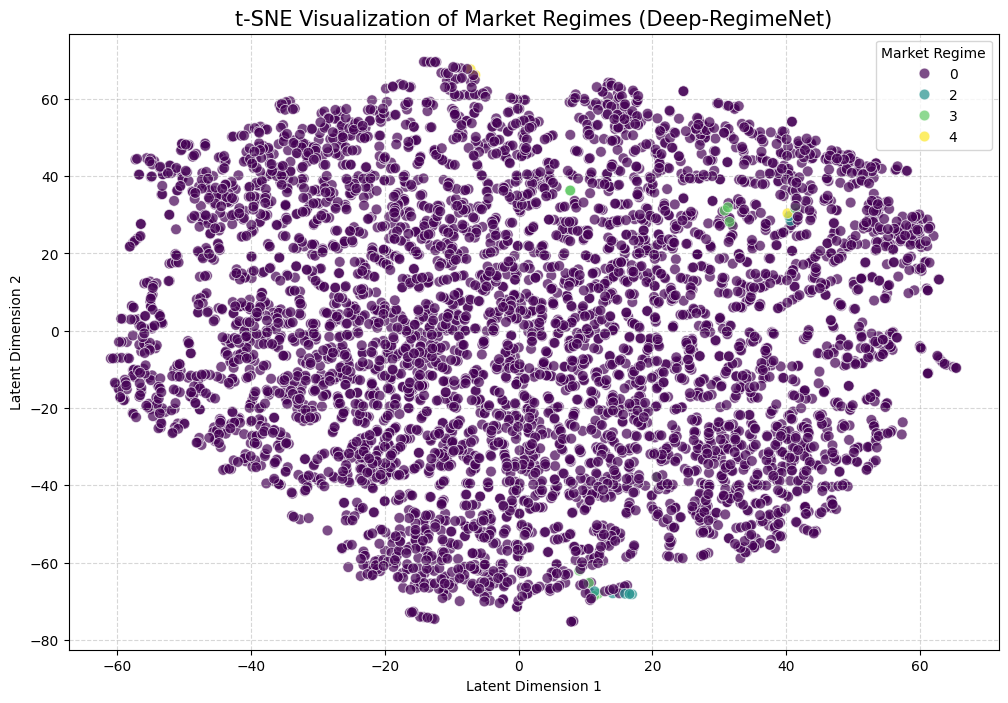

In [ ]:
def visualize_market_regimes(model, data_loader, scaler):
    """
    Extracts latent representations and projects them into 2D space via t-SNE.
    """
    model.eval()
    latents = []
    regime_labels = []

    # 1. Extract latent vectors and soft-assignments from the trained model
    with torch.no_grad():
        for batch in data_loader:
            x = batch[0]
            recon, q, latent = model(x)

            latents.append(latent.cpu().numpy())
            # Assign the regime label based on the highest probability
            regime_labels.append(torch.argmax(q, dim=1).cpu().numpy())

    latents = np.concatenate(latents)
    regime_labels = np.concatenate(regime_labels)

    # 2. Perform t-SNE Dimensionality Reduction
    print("Running t-SNE reduction...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    z_2d = tsne.fit_transform(latents)

    # 3. Plotting the Results
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        x=z_2d[:, 0], y=z_2d[:, 1],
        hue=regime_labels,
        palette='viridis',
        alpha=0.7,
        edgecolor='w',
        s=60
    )

    plt.title("t-SNE Visualization of Market Regimes (Deep-RegimeNet)", fontsize=15)
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.legend(title="Market Regime", loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Execution
visualize_market_regimes(trained_model, train_loader, data_scaler)

### Mapping Regimes to Historical Price Action

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


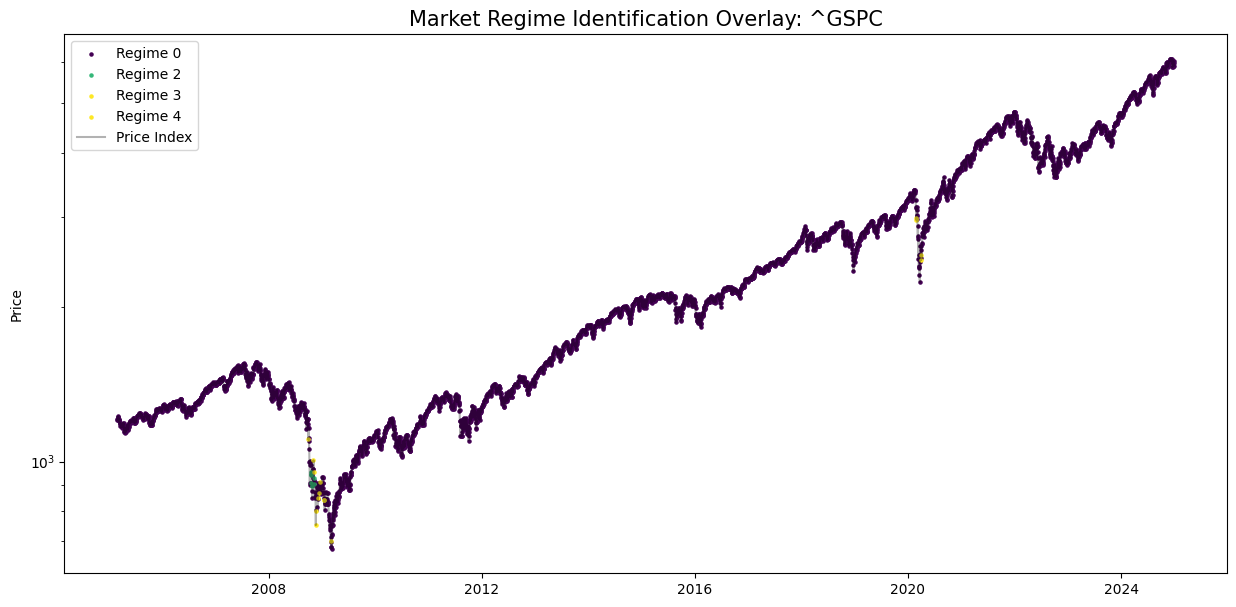

In [ ]:
def plot_regime_overlay(model, ticker="^GSPC", start="2005-01-01", end="2025-01-01", window_size=20):
    """
    Plots the price chart with colors representing the identified market regimes.
    """
    # 1. Fetch raw price data for plotting
    raw_data = yf.download(ticker, start=start, end=end)['Close']

    # 2. Re-process data to get regimes
    # The get_regime_data function removes 19 rows due to rolling features and then window_size for windows.
    # So, the number of effective days processed is len(raw_data) - 19 - window_size.
    X_tensor, _ = get_regime_data(ticker, start, end, window_size)
    model.eval()
    with torch.no_grad():
        _, q, _ = model(X_tensor)
        regimes = torch.argmax(q, dim=1).cpu().numpy()

    # 3. Align regimes with dates
    # The first regime corresponds to the end of the first window of the processed data.
    # The processed data starts effectively 19 days after the raw_data due to NaNs.
    # So, the first regime corresponds to original_data.index[19 + window_size - 1]

    start_plot_index = 19 + window_size - 1
    end_plot_index = len(raw_data) # Exclusive end, so covers up to len(raw_data) - 1

    plot_dates = raw_data.index[start_plot_index : end_plot_index]
    plot_prices = raw_data.values[start_plot_index : end_plot_index]

    # The regimes array has a length of (len(raw_data) - 19 - window_size).
    plot_dates = plot_dates[:len(regimes)]
    plot_prices = plot_prices[:len(regimes)]


    # 4. Create the Overlay Plot
    plt.figure(figsize=(15, 7))
    unique_regimes = np.unique(regimes)
    colors = cm.get_cmap('viridis', len(unique_regimes))

    for r in unique_regimes:
        mask = (regimes == r)
        plt.scatter(plot_dates[mask], plot_prices[mask], label=f'Regime {r}', s=5, color=colors(r))

    plt.plot(plot_dates, plot_prices, color='black', alpha=0.3, label='Price Index')
    plt.title(f"Market Regime Identification Overlay: {ticker}", fontsize=15)
    plt.ylabel("Price")
    plt.yscale('log')
    plt.legend()
    plt.show()

# Execution
plot_regime_overlay(trained_model)

### Implementation of DTW-KMeans Baseline

In [ ]:
%%capture
!pip install tslearn

In [ ]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance


def run_dtw_kmeans_baseline(X_train_tensor, n_clusters=4):
    """
    Implements the DTW-KMeans clustering baseline for financial time-series.
    """
    # 1. Convert PyTorch tensor back to NumPy and ensure correct shape for tslearn
    # tslearn expects: (n_samples, sz, d)
    X_train_np = X_train_tensor.cpu().numpy()

    # 2. Preprocessing: Mean-Variance Scaling (standard for DTW)
    # This ensures each window has zero mean and unit variance
    X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X_train_np)

    # 3. Initialize and Fit DTW-KMeans
    print(f"Fitting DTW-KMeans with {n_clusters} clusters...")
    dtw_km = TimeSeriesKMeans(
        n_clusters=n_clusters,
        metric="dtw",          # Use Dynamic Time Warping distance
        max_iter=10,           # DTW is computationally expensive
        random_state=42,
        n_jobs=-1
    )

    labels = dtw_km.fit_predict(X_scaled)
    print("Baseline fitting complete.")

    return dtw_km, labels

# Execution
dtw_model, dtw_labels = run_dtw_kmeans_baseline(X_train, n_clusters=5)

Fitting DTW-KMeans with 5 clusters...
Baseline fitting complete.


[*********************100%***********************]  1 of 1 completed


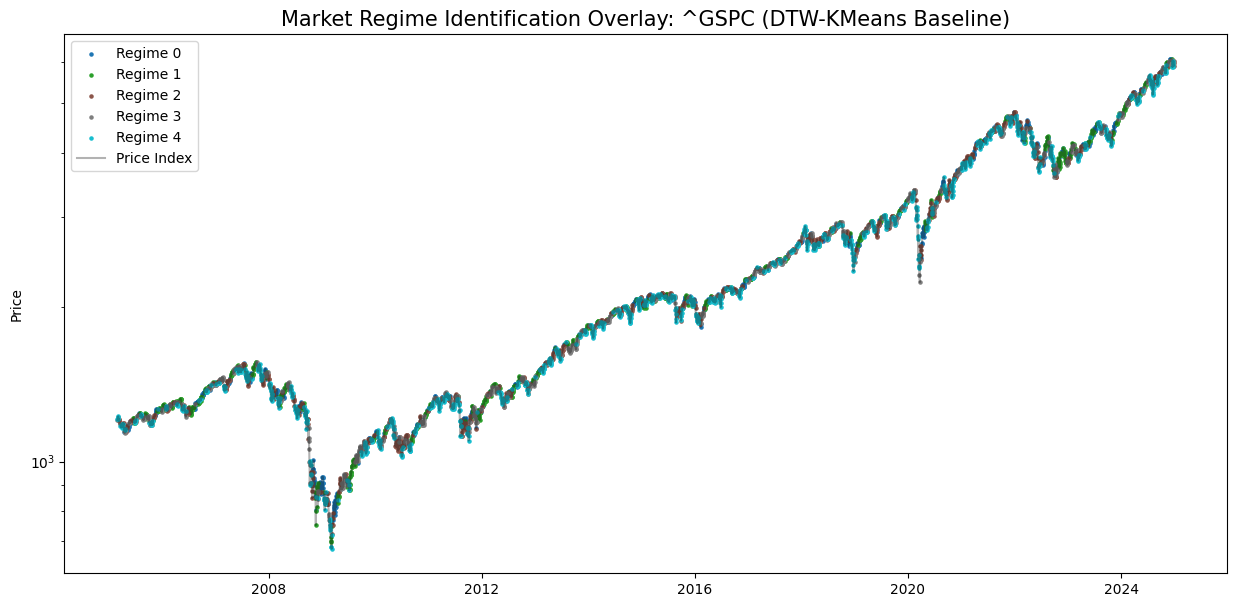

In [ ]:
import matplotlib.cm as cm

def plot_dtw_regime_overlay(dtw_labels, ticker="^GSPC", start="2005-01-01", end="2025-01-01", window_size=20):
    """
    Plots the price chart with colors representing the market regimes identified by DTW-KMeans.
    """
    # 1. Fetch raw price data for plotting
    raw_data = yf.download(ticker, start=start, end=end)['Close']

    # 2. Align regimes with dates
    # The original get_regime_data drops the first 19 rows due to rolling features and then window_size for windows.

    start_plot_index = 19 + window_size - 1
    end_plot_index = len(raw_data) # Exclusive end, so covers up to len(raw_data) - 1

    plot_dates = raw_data.index[start_plot_index : end_plot_index]
    plot_prices = raw_data.values[start_plot_index : end_plot_index]

    # Ensure plot_dates and plot_prices match the length of dtw_labels
    plot_dates = plot_dates[:len(dtw_labels)]
    plot_prices = plot_prices[:len(dtw_labels)]

    # 3. Create the Overlay Plot
    plt.figure(figsize=(15, 7))
    unique_regimes = np.unique(dtw_labels)
    colors = cm.get_cmap('tab10', len(unique_regimes)) # Using 'tab10' for distinct colors

    for r in unique_regimes:
        mask = (dtw_labels == r)
        plt.scatter(plot_dates[mask], plot_prices[mask], label=f'Regime {r}', s=5, color=colors(r))

    plt.plot(plot_dates, plot_prices, color='black', alpha=0.3, label='Price Index')
    plt.title(f"Market Regime Identification Overlay: {ticker} (DTW-KMeans Baseline)", fontsize=15)
    plt.ylabel("Price")
    plt.yscale('log')
    plt.legend()
    plt.show()

# Execution
plot_dtw_regime_overlay(dtw_labels)

### Implementation: Sequential AE + K-Means Baseline

In [ ]:
def run_sequential_ae_kmeans_baseline(model, train_loader, n_clusters=5):
    """
    Implements the Sequential AE + K-Means baseline.
    Steps:
    1. Pre-train AE (Reconstruction only)
    2. Extract latent features (Z)
    3. Apply K-Means to Z
    """
    # 1. Train Autoencoder (Reconstruction only)

    model.eval()
    all_latent = []

    # 2. Extract Latent Representations
    with torch.no_grad():
        for batch in train_loader:
            x = batch[0]
            latent, _ = model.ae(x) # Extract from AE backbone
            all_latent.append(latent.cpu().numpy())

    latents = np.concatenate(all_latent)

    # 3. Apply Standard K-Means
    print(f"Clustering latent space with K-Means (n_clusters={n_clusters})...")
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    labels = kmeans.fit_predict(latents)

    return kmeans, labels

In [ ]:
ae_kmeans_model, ae_kmeans_labels = run_sequential_ae_kmeans_baseline(model, train_loader, n_clusters=5)
print(f"Sequential AE + K-Means Baseline: {len(ae_kmeans_labels)} samples clustered into {len(np.unique(ae_kmeans_labels))} clusters.")

Clustering latent space with K-Means (n_clusters=5)...
Sequential AE + K-Means Baseline: 4994 samples clustered into 5 clusters.


[*********************100%***********************]  1 of 1 completed


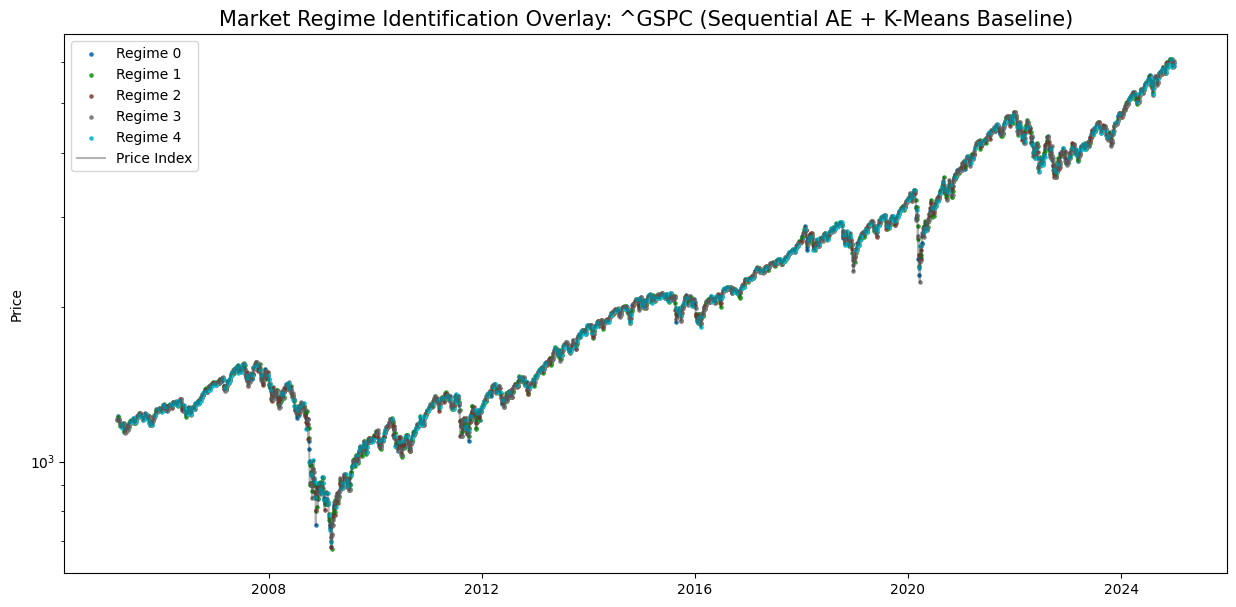

In [ ]:
def plot_ae_kmeans_regime_overlay(ae_kmeans_labels, ticker="^GSPC", start="2005-01-01", end="2025-01-01", window_size=20):
    """
    Plots the price chart with colors representing the market regimes identified by Sequential AE + K-Means.
    """
    # 1. Fetch raw price data for plotting
    raw_data = yf.download(ticker, start=start, end=end)['Close']

    # 2. Align regimes with dates
    start_plot_index = 19 + window_size - 1
    end_plot_index = len(raw_data) # Exclusive end, so covers up to len(raw_data) - 1

    plot_dates = raw_data.index[start_plot_index : end_plot_index]
    plot_prices = raw_data.values[start_plot_index : end_plot_index]

    # Ensure plot_dates and plot_prices match the length of ae_kmeans_labels
    plot_dates = plot_dates[:len(ae_kmeans_labels)]
    plot_prices = plot_prices[:len(ae_kmeans_labels)]

    # 3. Create the Overlay Plot
    plt.figure(figsize=(15, 7))
    unique_regimes = np.unique(ae_kmeans_labels)
    colors = cm.get_cmap('tab10', len(unique_regimes)) # Using 'tab10' for distinct colors

    for r in unique_regimes:
        mask = (ae_kmeans_labels == r)
        plt.scatter(plot_dates[mask], plot_prices[mask], label=f'Regime {r}', s=5, color=colors(r))

    plt.plot(plot_dates, plot_prices, color='black', alpha=0.3, label='Price Index')
    plt.title(f"Market Regime Identification Overlay: {ticker} (Sequential AE + K-Means Baseline)", fontsize=15)
    plt.ylabel("Price")
    plt.yscale('log') # Log scale is often better for long-term price charts
    plt.legend()
    plt.show()

# Execution
plot_ae_kmeans_regime_overlay(ae_kmeans_labels)

## Calculate DeepRegimeNet Metrics

Calculate the Silhouette Score and Reconstruction Loss for the DeepRegimeNet model. This involves extracting latent features and reconstruction from the trained model and then computing the metrics.


In [ ]:
from sklearn.metrics import silhouette_score

def get_deepregimenet_outputs(model, data_loader):
    model.eval()
    all_latents = []
    all_reconstructions = []
    all_labels = []
    all_inputs = []

    with torch.no_grad():
        for batch in data_loader:
            x = batch[0]
            recon, q, latent = model(x)

            all_latents.append(latent.cpu().numpy())
            all_reconstructions.append(recon.cpu().numpy())
            all_labels.append(torch.argmax(q, dim=1).cpu().numpy())
            all_inputs.append(x.cpu().numpy())

    return (
        np.concatenate(all_latents),
        np.concatenate(all_reconstructions),
        np.concatenate(all_labels),
        np.concatenate(all_inputs)
    )

In [ ]:
print("Calculating DeepRegimeNet Metrics...")
drn_latents, drn_reconstructions, drn_labels, drn_inputs = get_deepregimenet_outputs(trained_model, train_loader)


Calculating DeepRegimeNet Metrics...


In [ ]:
drn_silhouette_score = silhouette_score(drn_latents, drn_labels)
print(f"DeepRegimeNet - Silhouette Score: {drn_silhouette_score:.4f}")

DeepRegimeNet - Silhouette Score: 0.3684


In [ ]:
import torch.nn as nn
mse_loss_fn = nn.MSELoss()
drn_reconstruction_loss = mse_loss_fn(torch.tensor(drn_reconstructions), torch.tensor(drn_inputs)).item()
print(f"DeepRegimeNet - Reconstruction Loss: {drn_reconstruction_loss:.4f}")

DeepRegimeNet - Reconstruction Loss: 0.4171


## Calculate DTW-KMeans Baseline Silhouette Score
Calculate the Silhouette Score for the DTW-KMeans baseline model.



In [ ]:
print("\nCalculating DTW-KMeans Baseline Silhouette Score...")
# Need to re-scale X_train for DTW-KMeans as done in `run_dtw_kmeans_baseline`
X_train_np = X_train.cpu().numpy()
dtw_scaler = TimeSeriesScalerMeanVariance()
dtw_X_scaled = dtw_scaler.fit_transform(X_train_np)

# Flatten the scaled time series for silhouette_score using Euclidean distance
dtw_silhouette_score = silhouette_score(dtw_X_scaled.reshape(dtw_X_scaled.shape[0], -1), dtw_labels)

print(f"DTW-KMeans Baseline - Silhouette Score: {dtw_silhouette_score:.4f}")


Calculating DTW-KMeans Baseline Silhouette Score...
DTW-KMeans Baseline - Silhouette Score: 0.0130


### Implementation: Sequential AE + K-Means Baseline

In [ ]:
def get_ae_outputs(ae_model, data_loader):
    ae_model.eval()
    all_latents = []
    all_reconstructions = []
    all_inputs = []
    with torch.no_grad():
        for batch in data_loader:
            x = batch[0]
            latent, recon = ae_model(x) # Extract from AE backbone
            all_latents.append(latent.cpu().numpy())
            all_reconstructions.append(recon.cpu().numpy())
            all_inputs.append(x.cpu().numpy())

    latents = np.concatenate(all_latents)
    reconstructions = np.concatenate(all_reconstructions)
    inputs = np.concatenate(all_inputs)
    return latents, reconstructions, inputs

In [ ]:
print("\nCalculating Sequential AE + K-Means Baseline Metrics...")
# The 'model' variable is the DeepRegimeNet instance after training.
# Its 'ae' attribute corresponds to the autoencoder used in this baseline.
ae_latents, ae_reconstructions, ae_inputs = get_ae_outputs(model.ae, train_loader)

# Silhouette Score
ae_kmeans_silhouette_score = silhouette_score(ae_latents, ae_kmeans_labels)

# Reconstruction Loss
mse_loss_fn = nn.MSELoss()
ae_reconstruction_loss = mse_loss_fn(torch.tensor(ae_reconstructions), torch.tensor(ae_inputs)).item()

print(f"Sequential AE + K-Means Baseline - Silhouette Score: {ae_kmeans_silhouette_score:.4f}")
print(f"Sequential AE + K-Means Baseline - Reconstruction Loss: {ae_reconstruction_loss:.4f}")


Calculating Sequential AE + K-Means Baseline Metrics...
Sequential AE + K-Means Baseline - Silhouette Score: -0.0126
Sequential AE + K-Means Baseline - Reconstruction Loss: 0.4171


In [ ]:
print("\n--- Comparative Analysis of Clustering Models ---")
print("| Model                          | Silhouette Score | Reconstruction Loss |")
print("|--------------------------------|------------------|---------------------|")
print(f"| DeepRegimeNet                  | {drn_silhouette_score:.4f}           | {drn_reconstruction_loss:.4f}         |")
print(f"| DTW-KMeans Baseline            | {dtw_silhouette_score:.4f}           | N/A                 |")
print(f"| Sequential AE + K-Means Baseline | {ae_kmeans_silhouette_score:.4f}           | {ae_reconstruction_loss:.4f}         |")


--- Comparative Analysis of Clustering Models ---
| Model                          | Silhouette Score | Reconstruction Loss |
|--------------------------------|------------------|---------------------|
| DeepRegimeNet                  | 0.3684           | 0.4171         |
| DTW-KMeans Baseline            | 0.0130           | N/A                 |
| Sequential AE + K-Means Baseline | -0.0126           | 0.4171         |
